# **A Root-Zone Soil Moisture Bucket Model: Build, Calibrate, Evaluate**

The simplest useful hydrologic model: one bucket, rain in, evapotranspiration and drainage out, tested against measured soil moisture.

## **Learning objectives**

By the end of this tutorial you will be able to:

- Write the root-zone water balance and turn it into a daily bucket model.
- Represent soil moisture limitation on evapotranspiration with a stress function.
- Calibrate model parameters against observed soil moisture with an optimizer and the Nash-Sutcliffe efficiency.
- Evaluate the model on independent years and diagnose where it fails.

**Before you start:** Notebook 02 (PET) and Notebook 04 (soil water). Uses `scipy.optimize`.

## **The root-zone water balance**

Let $S$ (mm) be the water stored in the root zone of depth $Z_r$. Each day:

$$ \frac{dS}{dt} = P - ET - D - Q \qquad (1) $$

where $P$ is precipitation, $ET$ is evapotranspiration, $D$ is drainage below the root zone, and $Q$ is surface runoff.
The bucket model closes this balance with three simple rules:

1. **ET is limited by soil moisture.** $ET = PET \cdot \beta(S)$, where the stress function $\beta$ is 0 at the wilting point
   $S_w$, 1 above a critical storage $S^*$, and linear in between:
   $$ \beta(S) = \min\!\left(1, \max\!\left(0, \frac{S - S_w}{S^* - S_w}\right)\right) \qquad (2) $$
2. **Drainage happens above field capacity.** $D = k_d \,(S - S_{fc})$ for $S > S_{fc}$, else 0.
3. **Runoff occurs when the bucket overflows.** $Q = \max(0, S - S_{max})$.

Storage is converted to volumetric water content with $\theta = S / Z_r$. The model has a handful of parameters
($Z_r$, $\theta_w$, $\theta^*$, $\theta_{fc}$, $\theta_s$, $k_d$) that we calibrate against measured soil moisture.

**Site:** US-Var (Vaira Ranch). We drive the model with Daymet precipitation and the site's PET, and compare with the
measured soil water content `theta_2`.

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file, downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    os.makedirs('sample_data', exist_ok=True)
    out = os.path.join('sample_data', fname)
    urllib.request.urlretrieve(BASE + fname, out)
    return out

files = ['daily_data_UA-Var_2000_2021.csv', 'daymet_US-Var_2000_2021.csv']
paths = {f: get_data(f) for f in files}
paths

{'daily_data_UA-Var_2000_2021.csv': '..\\..\\sample_data\\daily_data_UA-Var_2000_2021.csv',
 'daymet_US-Var_2000_2021.csv': '..\\..\\sample_data\\daymet_US-Var_2000_2021.csv'}

In [2]:
df = pd.read_csv(paths['daily_data_UA-Var_2000_2021.csv'])
df['Date'] = pd.to_datetime(df['DateTime']); df = df.set_index('Date').drop(columns='DateTime')
dm = pd.read_csv(paths['daymet_US-Var_2000_2021.csv'], parse_dates=['Date']).set_index('Date')
d = df[['PET', 'theta_2', 'LE_F_MDS', 'TA_F']].join(dm[['P_mm']], how='inner')
d['PET_mm'] = d['PET'] * 86400 / ((2.501 - 0.002361 * d['TA_F']) * 1e6)      # PET column is in W m-2
d['ET_obs'] = d['LE_F_MDS'] * 86400 / ((2.501 - 0.002361 * d['TA_F']) * 1e6)
d = d.dropna(subset=['P_mm', 'PET_mm'])
print(d[['P_mm', 'PET_mm', 'ET_obs', 'theta_2']].describe().round(2))

          P_mm   PET_mm   ET_obs  theta_2
count  8030.00  8030.00  8030.00  7649.00
mean      1.74     2.44     0.83     0.17
std       6.00     1.43     0.88     0.10
min       0.00     0.00    -0.09     0.02
25%       0.00     1.18     0.13     0.09
50%       0.00     2.22     0.55     0.14
75%       0.00     3.78     1.16     0.26
max     140.01     6.01     4.44     0.47


## **Step 1: The model**

In [3]:
def bucket(P, PET, Zr=300., th_w=0.05, th_star=0.20, th_fc=0.30, th_s=0.45, kd=0.3, th0=0.15):
    """Daily root-zone bucket model. Inputs in mm/day, thresholds as volumetric water content. Returns theta, ET, D, Q."""
    n = len(P); S = np.zeros(n); ET = np.zeros(n); D = np.zeros(n); Q = np.zeros(n)
    Sw, Sstar, Sfc, Smax = th_w * Zr, th_star * Zr, th_fc * Zr, th_s * Zr
    s = th0 * Zr
    for t in range(n):
        s = s + P[t]
        Q[t] = max(0.0, s - Smax); s -= Q[t]                                   # overflow
        beta = np.clip((s - Sw) / max(Sstar - Sw, 1e-6), 0, 1)
        ET[t] = min(PET[t] * beta, max(s - Sw, 0)); s -= ET[t]                # stress-limited ET
        D[t] = kd * max(0.0, s - Sfc); s -= D[t]                              # drainage
        S[t] = s
    return S / Zr, ET, D, Q

def nse(sim, obs):
    m = ~np.isnan(obs)
    return 1 - np.sum((sim[m] - obs[m]) ** 2) / np.sum((obs[m] - np.nanmean(obs)) ** 2)

theta0, ET0, D0, Q0 = bucket(d['P_mm'].values, d['PET_mm'].values)
print(f'Default parameters: NSE = {nse(theta0, d["theta_2"].values):.2f}')

Default parameters: NSE = 0.77


## **Step 2: Calibrate on 2000-2012, keep 2013-2021 for validation**

In [4]:
cal = d.index < '2013-01-01'
P, PET, obs = d['P_mm'].values, d['PET_mm'].values, d['theta_2'].values
names = ['Zr', 'th_w', 'th_star', 'th_fc', 'th_s', 'kd']
x0 = [300, 0.05, 0.20, 0.30, 0.45, 0.3]
bounds = [(100, 800), (0.02, 0.12), (0.10, 0.35), (0.20, 0.42), (0.35, 0.50), (0.02, 1.0)]

def objective(x):
    p = dict(zip(names, x))
    if not (p['th_w'] < p['th_star'] < p['th_fc'] < p['th_s']):
        return 10.0
    th, *_ = bucket(P, PET, **p)
    return -nse(th[cal], obs[cal])

res = minimize(objective, x0, bounds=bounds, method='Nelder-Mead', options={'maxiter': 800, 'xatol': 1e-3, 'fatol': 1e-4})
best = dict(zip(names, res.x))
theta_sim, ET_sim, D_sim, Q_sim = bucket(P, PET, **best)
print('Calibrated parameters:'); print(pd.Series(best).round(3))
print(f'NSE calibration (2000-2012) = {nse(theta_sim[cal], obs[cal]):.2f}')
print(f'NSE validation  (2013-2021) = {nse(theta_sim[~cal], obs[~cal]):.2f}')

Calibrated parameters:
Zr         556.019
th_w         0.076
th_star      0.195
th_fc        0.276
th_s         0.350
kd           0.368
dtype: float64
NSE calibration (2000-2012) = 0.93
NSE validation  (2013-2021) = 0.82


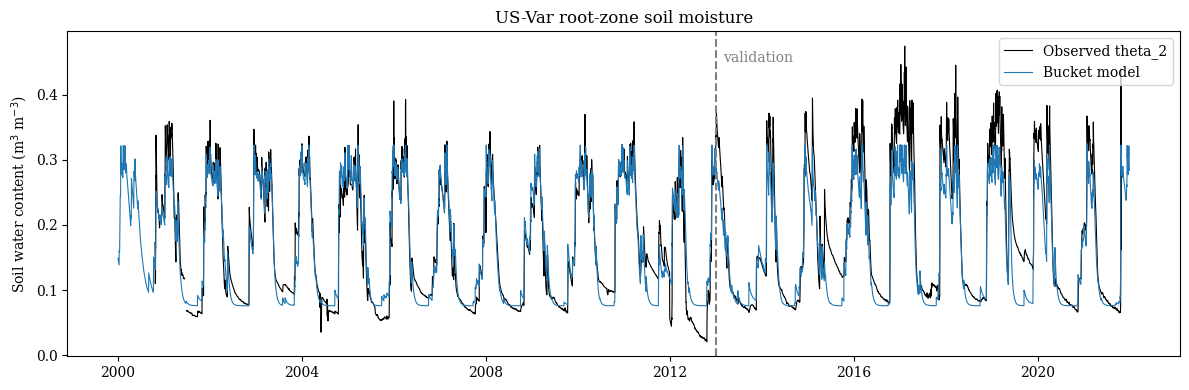

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d.index, obs, 'k', lw=0.8, label='Observed theta_2')
ax.plot(d.index, theta_sim, 'tab:blue', lw=0.8, label='Bucket model')
ax.axvline(pd.Timestamp('2013-01-01'), color='grey', ls='--'); ax.text(pd.Timestamp('2013-03-01'), 0.45, 'validation', color='grey')
ax.set_ylabel('Soil water content (m$^3$ m$^{-3}$)'); ax.legend(loc='upper right'); ax.set_title('US-Var root-zone soil moisture'); plt.tight_layout()

## **Step 3: Look closer at one wet year and one drought year**

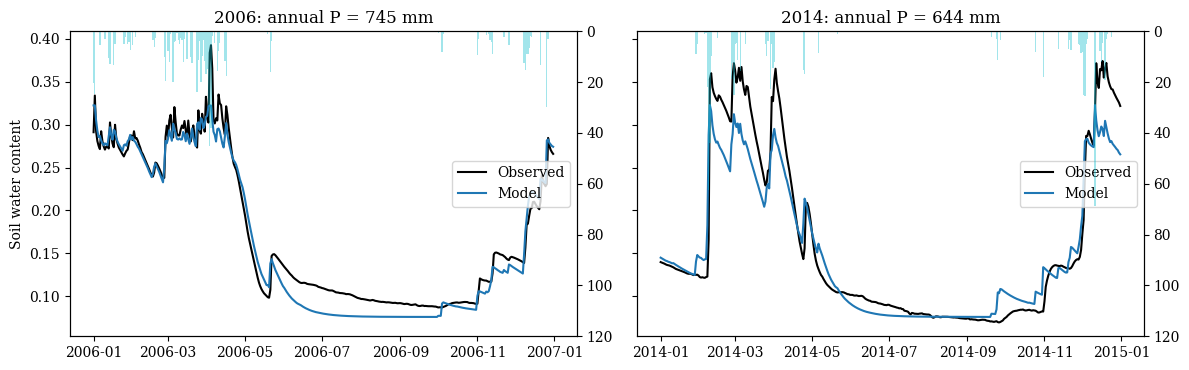

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, yr in zip(axs, ['2006', '2014']):
    sl = d.loc[yr]; idx = d.index.get_indexer(sl.index)
    ax.plot(sl.index, obs[idx], 'k', label='Observed'); ax.plot(sl.index, theta_sim[idx], 'tab:blue', label='Model')
    ax2 = ax.twinx(); ax2.bar(sl.index, sl['P_mm'], color='tab:cyan', alpha=0.4, width=1); ax2.set_ylim(0, 120); ax2.invert_yaxis()
    ax.set_title(f'{yr}: annual P = {sl["P_mm"].sum():.0f} mm'); ax.legend(loc='center right')
axs[0].set_ylabel('Soil water content'); axs[1].yaxis.set_label_position('right'); plt.tight_layout()

**What to notice.** The model captures the wet-up after the first autumn rains and the spring dry-down well, because
those are controlled by the water balance the model contains. It tends to miss the details of the summer minimum and the
speed of individual wetting events. Those depend on processes the bucket ignores: layered soils, hydraulic
redistribution, deep roots drawing from below the modeled root zone, and rain that is intercepted by the canopy.

## **Step 4: How does the model partition the water?**

In [7]:
out = pd.DataFrame({'P': P, 'ET': ET_sim, 'D': D_sim, 'Q': Q_sim, 'ET_obs': d['ET_obs'].values}, index=d.index).resample('YE').sum()
out.index = out.index.year
print(out.round(0))
print(f"\nMean annual: P {out['P'].mean():.0f} mm, modeled ET {out['ET'].mean():.0f} mm, observed ET {out['ET_obs'].mean():.0f} mm, drainage {out['D'].mean():.0f} mm, runoff {out['Q'].mean():.0f} mm")

           P     ET      D      Q  ET_obs
Date                                     
2000   796.0  372.0  310.0   80.0   303.0
2001   602.0  295.0  258.0    0.0   291.0
2002   521.0  293.0  231.0    1.0   274.0
2003   523.0  370.0  142.0    0.0   329.0
2004   551.0  269.0  256.0   20.0   265.0
2005   841.0  392.0  407.0   44.0   385.0
2006   745.0  331.0  367.0   71.0   315.0
2007   428.0  316.0  122.0    6.0   273.0
2008   493.0  261.0  207.0   22.0   234.0
2009   505.0  322.0  172.0    0.0   322.0
2010   859.0  414.0  417.0   20.0   345.0
2011   556.0  409.0  236.0    7.0   334.0
2012   717.0  316.0  283.0   29.0   289.0
2013   213.0  275.0   12.0    0.0   247.0
2014   644.0  330.0  212.0   36.0   287.0
2015   453.0  348.0   81.0   19.0   302.0
2016   861.0  372.0  440.0   49.0   335.0
2017  1074.0  388.0  491.0  212.0   299.0
2018   657.0  341.0  278.0   21.0   300.0
2019   861.0  395.0  447.0   25.0   356.0
2020   362.0  326.0   82.0    1.0   301.0
2021   705.0  289.0  299.0   58.0 

Modeled ET should be close to the measured ET (which the model never saw). If it is not, the calibration has forced
soil moisture to fit at the expense of the fluxes, a common problem when a model is calibrated on one variable only.
Multi-variable calibration (soil moisture and ET together) is one fix, and one of the exercises.

## **Exercises**

**Exercise 1.** Calibrate on 2013-2021 and validate on 2000-2012. Do the parameters change? What does that say about their physical meaning?

**Exercise 2.** Add the observed ET to the objective: minimize $-(NSE_\theta + NSE_{ET})/2$. How do the water balance components change?

**Exercise 3.** Replace the linear stress function with a nonlinear one, $\beta = \left(\frac{S - S_w}{S^* - S_w}\right)^{2}$. Does it fit the dry-down better?

**Exercise 4.** The model has no canopy interception. Add a simple interception store (for example, 1 mm per day of rain when LAI > 1) and see whether the wet-season peaks improve.

## **References**

- Laio, F., Porporato, A., Ridolfi, L., & Rodriguez-Iturbe, I. (2001). Plants in water-controlled ecosystems: active role in hydrologic processes and response to water stress. II. Probabilistic soil moisture dynamics. *Advances in Water Resources*, 24, 707-723.
- Rodriguez-Iturbe, I., & Porporato, A. (2004). *Ecohydrology of Water-Controlled Ecosystems.* Cambridge University Press.
- Nash, J. E., & Sutcliffe, J. V. (1970). River flow forecasting through conceptual models part I. *Journal of Hydrology*, 10, 282-290.
- Raghav, P., & Kumar, M. (2021). Retrieving gap-free daily root zone soil moisture using surface flux equilibrium theory. *Environmental Research Letters*, 16, 104007.